In [16]:
from project.utilities.simulation import run_trials, run_task, TrialParams, run_experiments, DotsParams, get_CI
from project.utilities.statistics import bootstrap_ci, bootstrap_difference_ci
from project.utilities.io import load_results, save_plot, use_latex_fonts, figure_size

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import SeedSequence, default_rng
from dataclasses import asdict, replace
from scipy.stats import bootstrap
from statsmodels.stats.proportion import proportion_confint

from pathlib import Path
import pandas as pd

from project.networks.cbgt import ModelParams, ThalamusParams, BGParams, CBGT
from project.networks.cortex import CortexParams

# For displaying
from IPython.display import display, HTML

# Change font of plots
use_latex_fonts()

# Import Data

### Summary Statistics

Importing the data generated by `scripts/suite5.py`

In [17]:
summary_stats_2 = load_results('suite5_2_summary.csv', '../../data/model realizations') 
summary_stats_3 = load_results('suite5_3_summary.csv', '../../data/model realizations')
summary_stats_4 = load_results('suite5_4_summary.csv', '../../data/model realizations')


Loaded: ..\..\data\model realizations\suite5_2_summary.csv
Loaded: ..\..\data\model realizations\suite5_3_summary.csv
Loaded: ..\..\data\model realizations\suite5_4_summary.csv


The model paramaters are carefully designed not to give rise to any premature decision. For completeness, this can quickly be verified.

In [18]:
print('Amount of premature decision with model seed = 2:', summary_stats_2['Premature (%)'].sum())
print('Amount of premature decision with model seed = 3:', summary_stats_3['Premature (%)'].sum())
print('Amount of premature decision with model seed = 4:', summary_stats_4['Premature (%)'].sum())

Amount of premature decision with model seed = 2: 0.0
Amount of premature decision with model seed = 3: 0.0
Amount of premature decision with model seed = 4: 0.0


As expected, no premature decisions.

# Plotting Data

Plotting relevant summary statistics. No further analysis will be done. It will only quickly be verified that different model seeds will lead to similar results

### Accuracy, post-decision variability and mistakes vs coherence

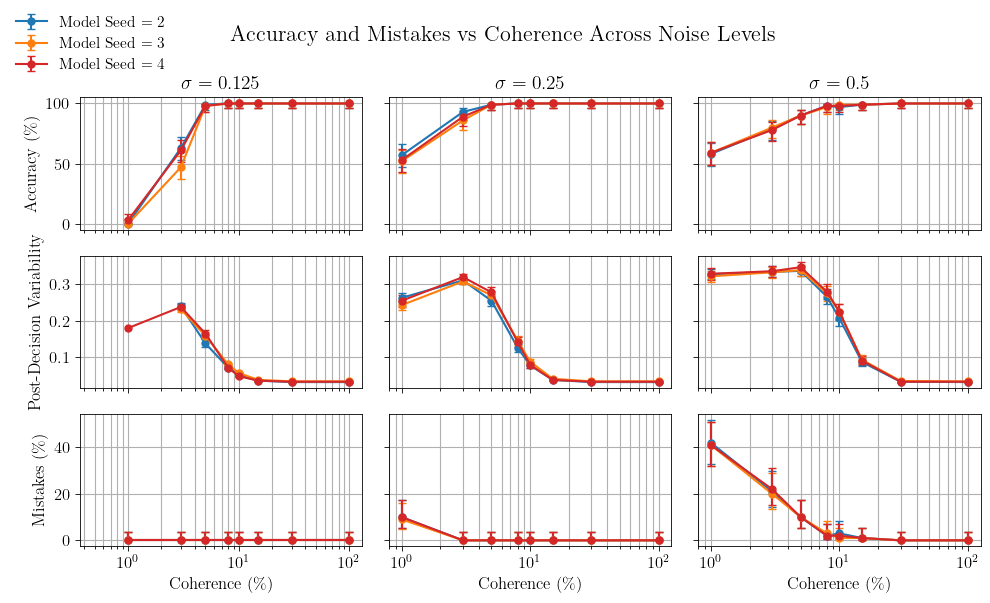

Saved: ..\..\figures\model realizations\suite5\Accuracy and Mistakes vs Coherence.pdf
Saved: ..\..\figures\model realizations\suite5\Accuracy and Mistakes vs Coherence.png


In [19]:
# ===== Split data by noise level =====
# Model seed = 2
df_0125_2 = summary_stats_2[summary_stats_2['noise_std'] == 0.125]
df_025_2 = summary_stats_2[summary_stats_2['noise_std'] == 0.25]
df_05_2 = summary_stats_2[summary_stats_2['noise_std'] == 0.5]

# Model seed = 3
df_0125_3 = summary_stats_3[summary_stats_3['noise_std'] == 0.125]
df_025_3 = summary_stats_3[summary_stats_3['noise_std'] == 0.25]
df_05_3 = summary_stats_3[summary_stats_3['noise_std'] == 0.5]

# Model seed = 4
df_0125_4 = summary_stats_4[summary_stats_4['noise_std'] == 0.125]
df_025_4 = summary_stats_4[summary_stats_4['noise_std'] == 0.25]
df_05_4 = summary_stats_4[summary_stats_4['noise_std'] == 0.5]


# ==== Get mean and confidence intervals for each noise level ====
# --- Accuracy ---
acc_0125_2, acc_err_0125_2 = get_CI(df_0125_2, metric='Accuracy (%)')
acc_025_2, acc_err_025_2 = get_CI(df_025_2, metric='Accuracy (%)')
acc_05_2, acc_err_05_2 = get_CI(df_05_2, metric='Accuracy (%)')

acc_0125_3, acc_err_0125_3 = get_CI(df_0125_3, metric='Accuracy (%)')
acc_025_3, acc_err_025_3 = get_CI(df_025_3, metric='Accuracy (%)')
acc_05_3, acc_err_05_3 = get_CI(df_05_3, metric='Accuracy (%)')

acc_0125_4, acc_err_0125_4 = get_CI(df_0125_4, metric='Accuracy (%)')
acc_025_4, acc_err_025_4 = get_CI(df_025_4, metric='Accuracy (%)')
acc_05_4, acc_err_05_4 = get_CI(df_05_4, metric='Accuracy (%)')

# --- Post-decision variability ---
pdv_0125_2, pdv_err_0125_2 = get_CI(df_0125_2, metric='Mean PD Variability')
pdv_025_2, pdv_err_025_2 = get_CI(df_025_2, metric='Mean PD Variability')
pdv_05_2, pdv_err_05_2 = get_CI(df_05_2, metric='Mean PD Variability')

pdv_0125_3, pdv_err_0125_3 = get_CI(df_0125_3, metric='Mean PD Variability')
pdv_025_3, pdv_err_025_3 = get_CI(df_025_3, metric='Mean PD Variability')
pdv_05_3, pdv_err_05_3 = get_CI(df_05_3, metric='Mean PD Variability')

pdv_0125_4, pdv_err_0125_4 = get_CI(df_0125_4, metric='Mean PD Variability')
pdv_025_4, pdv_err_025_4 = get_CI(df_025_4, metric='Mean PD Variability')
pdv_05_4, pdv_err_05_4 = get_CI(df_05_4, metric='Mean PD Variability')

# --- Mistakes ---
mistakes_0125_2, mistakes_err_0125_2 = get_CI(df_0125_2, metric='Wrong Decision (%)')
mistakes_025_2, mistakes_err_025_2 = get_CI(df_025_2, metric='Wrong Decision (%)')
mistakes_05_2, mistakes_err_05_2 = get_CI(df_05_2, metric='Wrong Decision (%)')

mistakes_0125_3, mistakes_err_0125_3 = get_CI(df_0125_3, metric='Wrong Decision (%)')
mistakes_025_3, mistakes_err_025_3 = get_CI(df_025_3, metric='Wrong Decision (%)')
mistakes_05_3, mistakes_err_05_3 = get_CI(df_05_3, metric='Wrong Decision (%)')

mistakes_0125_4, mistakes_err_0125_4 = get_CI(df_0125_4, metric='Wrong Decision (%)')
mistakes_025_4, mistakes_err_025_4 = get_CI(df_025_4, metric='Wrong Decision (%)')
mistakes_05_4, mistakes_err_05_4 = get_CI(df_05_4, metric='Wrong Decision (%)')

# ==== Plotting ====
coherences = summary_stats_2['coherence'].unique() * 100
fig, ax = plt.subplots(3, 3, figsize=(10, 6), subplot_kw={"xscale": "log"}, sharex='col', sharey='row')

# Accuracy
ax[0, 0].errorbar(x=coherences, y=acc_0125_2, yerr=acc_err_0125_2, fmt='o-', capsize=3, markersize=5, label=r'Model Seed $= 2$')
ax[0, 0].errorbar(x=coherences, y=acc_0125_3, yerr=acc_err_0125_3, fmt='o-', capsize=3, markersize=5, label=r'Model Seed $= 3$')
ax[0, 0].errorbar(x=coherences, y=acc_0125_4, yerr=acc_err_0125_4, fmt='o-', capsize=3, markersize=5, label=r'Model Seed $= 4$', color = 'tab:red')
ax[0, 0].set_title('$\\sigma = 0.125$')
ax[0, 0].set_ylabel('Accuracy (\\%)')
ax[0, 0].grid(which='both')

ax[0, 1].errorbar(x=coherences, y=acc_025_2, yerr=acc_err_025_2, fmt='o-', capsize=3, markersize=5)
ax[0, 1].errorbar(x=coherences, y=acc_025_3, yerr=acc_err_025_3, fmt='o-', capsize=3, markersize=5)
ax[0, 1].errorbar(x=coherences, y=acc_025_4, yerr=acc_err_025_4, fmt='o-', capsize=3, markersize=5, color = 'tab:red')
ax[0, 1].set_title('$\\sigma = 0.25$')
ax[0, 1].grid(which='both')

ax[0, 2].errorbar(x=coherences, y=acc_05_2, yerr=acc_err_05_2, fmt='o-', capsize=3, markersize=5)
ax[0, 2].errorbar(x=coherences, y=acc_05_3, yerr=acc_err_05_3, fmt='o-', capsize=3, markersize=5)
ax[0, 2].errorbar(x=coherences, y=acc_05_4, yerr=acc_err_05_4, fmt='o-', capsize=3, markersize=5, color = 'tab:red')
ax[0, 2].set_title('$\\sigma = 0.5$')
ax[0, 2].grid(which='both')

# Post-decision variability
ax[1, 0].errorbar(x=coherences, y=pdv_0125_2, yerr=pdv_err_0125_2, fmt='o-', capsize=3, markersize=5)
ax[1, 0].errorbar(x=coherences, y=pdv_0125_3, yerr=pdv_err_0125_3, fmt='o-', capsize=3, markersize=5)
ax[1, 0].errorbar(x=coherences, y=pdv_0125_4, yerr=pdv_err_0125_4, fmt='o-', capsize=3, markersize=5, color = 'tab:red')
ax[1, 0].set_ylabel('Post-Decision Variability')
ax[1, 0].grid(which='both')

ax[1, 1].errorbar(x=coherences, y=pdv_025_2, yerr=pdv_err_025_2, fmt='o-', capsize=3, markersize=5)
ax[1, 1].errorbar(x=coherences, y=pdv_025_3, yerr=pdv_err_025_3, fmt='o-', capsize=3, markersize=5)
ax[1, 1].errorbar(x=coherences, y=pdv_025_4, yerr=pdv_err_025_4, fmt='o-', capsize=3, markersize=5, color = 'tab:red')
ax[1, 1].grid(which='both')

ax[1, 2].errorbar(x=coherences, y=pdv_05_2, yerr=pdv_err_05_2, fmt='o-', capsize=3, markersize=5)
ax[1, 2].errorbar(x=coherences, y=pdv_05_3, yerr=pdv_err_05_3, fmt='o-', capsize=3, markersize=5)
ax[1, 2].errorbar(x=coherences, y=pdv_05_4, yerr=pdv_err_05_4, fmt='o-', capsize=3, markersize=5, color = 'tab:red')
ax[1, 2].grid(which='both')

# Mistakes
ax[2, 0].errorbar(x=coherences, y=mistakes_0125_2, yerr=mistakes_err_0125_2, fmt='o-', capsize=3, markersize=5)
ax[2, 0].errorbar(x=coherences, y=mistakes_0125_3, yerr=mistakes_err_0125_3, fmt='o-', capsize=3, markersize=5)
ax[2, 0].errorbar(x=coherences, y=mistakes_0125_4, yerr=mistakes_err_0125_4, fmt='o-', capsize=3, markersize=5, color = 'tab:red')
ax[2, 0].set_xlabel('Coherence (\\%)')
ax[2, 0].set_ylabel('Mistakes (\\%)')
ax[2, 0].grid(which='both')

ax[2, 1].errorbar(x=coherences, y=mistakes_025_2, yerr=mistakes_err_025_2, fmt='o-', capsize=3, markersize=5)
ax[2, 1].errorbar(x=coherences, y=mistakes_025_3, yerr=mistakes_err_025_3, fmt='o-', capsize=3, markersize=5)
ax[2, 1].errorbar(x=coherences, y=mistakes_025_4, yerr=mistakes_err_025_4, fmt='o-', capsize=3, markersize=5, color = 'tab:red')
ax[2, 1].set_xlabel('Coherence (\\%)')
ax[2, 1].grid(which='both')

ax[2, 2].errorbar(x=coherences, y=mistakes_05_2, yerr=mistakes_err_05_2, fmt='o-', capsize=3, markersize=5)
ax[2, 2].errorbar(x=coherences, y=mistakes_05_3, yerr=mistakes_err_05_3, fmt='o-', capsize=3, markersize=5)
ax[2, 2].errorbar(x=coherences, y=mistakes_05_4, yerr=mistakes_err_05_4, fmt='o-', capsize=3, markersize=5, color = 'tab:red')
ax[2, 2].set_xlabel('Coherence (\\%)')
ax[2, 2].grid(which='both')

fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.95), frameon=False)
plt.suptitle('Accuracy and Mistakes vs Coherence Across Noise Levels')
plt.tight_layout()
plt.show()

# Save plot
save_plot(fig, 'Accuracy and Mistakes vs Coherence', folder='../../figures/model realizations/suite5', formats=('pdf', 'png'))

### Difference in Left and Right Accuracy

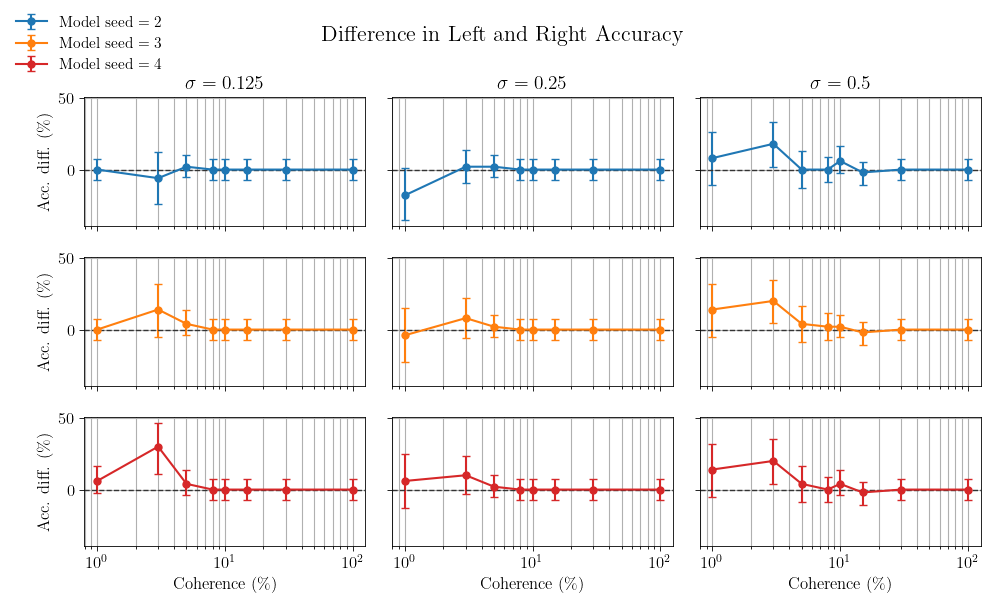

Saved: ..\..\figures\model realizations\suite5\Difference in Left and Right Accuracy vs Coherence.pdf
Saved: ..\..\figures\model realizations\suite5\Difference in Left and Right Accuracy vs Coherence.png


In [20]:
# ==== Get mean and confidence intervals for each noise level ====
# --- Model seed = 2 ---
acc_diff_0125_2, acc_diff_err_0125_2 = get_CI(df_0125_2, metric='Accuracy Difference (%)')
acc_diff_025_2, acc_diff_err_025_2 = get_CI(df_025_2, metric='Accuracy Difference (%)')
acc_diff_05_2, acc_diff_err_05_2 = get_CI(df_05_2, metric='Accuracy Difference (%)')

# --- Model seed = 3 ---
acc_diff_0125_3, acc_diff_err_0125_3 = get_CI(df_0125_3, metric='Accuracy Difference (%)')
acc_diff_025_3, acc_diff_err_025_3 = get_CI(df_025_3, metric='Accuracy Difference (%)')
acc_diff_05_3, acc_diff_err_05_3 = get_CI(df_05_3, metric='Accuracy Difference (%)')

# --- Model seed = 4 ---
acc_diff_0125_4, acc_diff_err_0125_4 = get_CI(df_0125_4, metric='Accuracy Difference (%)')
acc_diff_025_4, acc_diff_err_025_4 = get_CI(df_025_4, metric='Accuracy Difference (%)')
acc_diff_05_4, acc_diff_err_05_4 = get_CI(df_05_4, metric='Accuracy Difference (%)')


# ==== Plotting ====
fig, ax = plt.subplots(3, 3, figsize=(10,6), subplot_kw={"xscale": "log"}, sharex='col', sharey=True)

# Model seed = 2
ax[0, 0].errorbar(x=coherences, y=acc_diff_0125_2, yerr=acc_diff_err_0125_2, fmt='o-', capsize=3, markersize=5, label=r'Model seed $= 2$')
ax[0, 0].set_title('$\\sigma = 0.125$')
ax[0, 0].set_ylabel('Acc. diff. (\\%)')
ax[0, 0].grid(which='both')
ax[0, 0].axhline(0, color='0.2', linestyle='--', linewidth=1)

ax[0, 1].errorbar(x=coherences, y=acc_diff_025_2, yerr=acc_diff_err_025_2, fmt='o-', capsize=3, markersize=5)
ax[0, 1].set_title('$\\sigma = 0.25$')
ax[0, 1].grid(which='both')
ax[0, 1].axhline(0, color='0.2', linestyle='--', linewidth=1)

ax[0, 2].errorbar(x=coherences, y=acc_diff_05_2, yerr=acc_diff_err_05_2, fmt='o-', capsize=3, markersize=5)
ax[0, 2].set_title('$\\sigma = 0.5$')
ax[0, 2].grid(which='both')
ax[0, 2].axhline(0, color='0.2', linestyle='--', linewidth=1)

# Model seed = 3
ax[1, 0].errorbar(x=coherences, y=acc_diff_0125_3, yerr=acc_diff_err_0125_3, fmt='o-', capsize=3, markersize=5, label=r'Model seed $= 3$', color='tab:orange')
ax[1, 0].set_ylabel('Acc. diff. (\\%)')
ax[1, 0].grid(which='both')
ax[1, 0].axhline(0, color='0.2', linestyle='--', linewidth=1)

ax[1, 1].errorbar(x=coherences, y=acc_diff_025_3, yerr=acc_diff_err_025_3, fmt='o-', capsize=3, markersize=5, color='tab:orange')
ax[1, 1].grid(which='both')
ax[1, 1].axhline(0, color='0.2', linestyle='--', linewidth=1)

ax[1, 2].errorbar(x=coherences, y=acc_diff_05_3, yerr=acc_diff_err_05_3, fmt='o-', capsize=3, markersize=5, color='tab:orange')
ax[1, 2].grid(which='both')
ax[1, 2].axhline(0, color='0.2', linestyle='--', linewidth=1)

# Model seed = 4
ax[2, 0].errorbar(x=coherences, y=acc_diff_0125_4, yerr=acc_diff_err_0125_4, fmt='o-', capsize=3, markersize=5, label=r'Model seed $= 4$', color='tab:red')
ax[2, 0].set_xlabel('Coherence (\\%)')
ax[2, 0].set_ylabel('Acc. diff. (\\%)')
ax[2, 0].grid(which='both')
ax[2, 0].axhline(0, color='0.2', linestyle='--', linewidth=1)

ax[2, 1].errorbar(x=coherences, y=acc_diff_025_4, yerr=acc_diff_err_025_4, fmt='o-', capsize=3, markersize=5, color='tab:red')
ax[2, 1].set_xlabel('Coherence (\\%)')
ax[2, 1].grid(which='both')
ax[2, 1].axhline(0, color='0.2', linestyle='--', linewidth=1)

ax[2, 2].errorbar(x=coherences, y=acc_diff_05_4, yerr=acc_diff_err_05_4, fmt='o-', capsize=3, markersize=5, color='tab:red')
ax[2, 2].set_xlabel('Coherence (\\%)')
ax[2, 2].grid(which='both')
ax[2, 2].axhline(0, color='0.2', linestyle='--', linewidth=1)

fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.95), frameon=False)
plt.suptitle('Difference in Left and Right Accuracy')
plt.tight_layout()
plt.show()

# Save plot
save_plot(fig, 'Difference in Left and Right Accuracy vs Coherence', folder='../../figures/model realizations/suite5', formats=('pdf', 'png'))


### Reaction Times

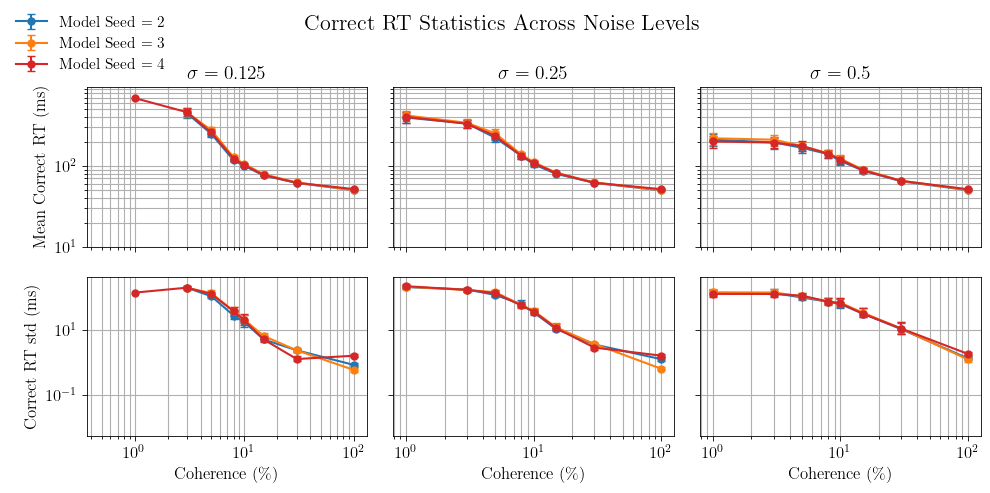

Saved: ..\..\figures\model realizations\suite5\Correct RT - Mean and Standard Deviation vs Coherence.pdf
Saved: ..\..\figures\model realizations\suite5\Correct RT - Mean and Standard Deviation vs Coherence.png


In [21]:
## ==== Get RT mean and std along with confidence intervals for each noise level ====
# --- RT Mean ---
RT_mean_0125_2, RT_err_0125_2 = get_CI(df_0125_2, metric='Mean Correct RT (ms)')
RT_mean_025_2, RT_err_025_2 = get_CI(df_025_2, metric='Mean Correct RT (ms)')
RT_mean_05_2, RT_err_05_2 = get_CI(df_05_2, metric='Mean Correct RT (ms)')

RT_mean_0125_3, RT_err_0125_3 = get_CI(df_0125_3, metric='Mean Correct RT (ms)')
RT_mean_025_3, RT_err_025_3 = get_CI(df_025_3, metric='Mean Correct RT (ms)')
RT_mean_05_3, RT_err_05_3 = get_CI(df_05_3, metric='Mean Correct RT (ms)')

RT_mean_0125_4, RT_err_0125_4 = get_CI(df_0125_4, metric='Mean Correct RT (ms)')
RT_mean_025_4, RT_err_025_4 = get_CI(df_025_4, metric='Mean Correct RT (ms)')
RT_mean_05_4, RT_err_05_4 = get_CI(df_05_4, metric='Mean Correct RT (ms)')

# --- RT std ---
RT_std_0125_2, RT_std_err_0125_2 = get_CI(df_0125_2, metric='Correct RT std (ms)')
RT_std_025_2, RT_std_err_025_2 = get_CI(df_025_2, metric='Correct RT std (ms)')
RT_std_05_2, RT_std_err_05_2 = get_CI(df_05_2, metric='Correct RT std (ms)')

RT_std_0125_3, RT_std_err_0125_3 = get_CI(df_0125_3, metric='Correct RT std (ms)')
RT_std_025_3, RT_std_err_025_3 = get_CI(df_025_3, metric='Correct RT std (ms)')
RT_std_05_3, RT_std_err_05_3 = get_CI(df_05_3, metric='Correct RT std (ms)')

RT_std_0125_4, RT_std_err_0125_4 = get_CI(df_0125_4, metric='Correct RT std (ms)')
RT_std_025_4, RT_std_err_025_4 = get_CI(df_025_4, metric='Correct RT std (ms)')
RT_std_05_4, RT_std_err_05_4 = get_CI(df_05_4, metric='Correct RT std (ms)')


# ==== Plotting ====
fig, ax = plt.subplots(2, 3, figsize=(10, 5), subplot_kw={"xscale": "log", "yscale": "log"}, sharex='col', sharey='row')

# RT Mean
ax[0, 0].errorbar(x=coherences, y=RT_mean_0125_2, yerr=RT_err_0125_2, fmt='o-', capsize=3, markersize=5, label=r'Model Seed $= 2$')
ax[0, 0].errorbar(x=coherences, y=RT_mean_0125_3, yerr=RT_err_0125_3, fmt='o-', capsize=3, markersize=5, label=r'Model Seed $= 3$')
ax[0, 0].errorbar(x=coherences, y=RT_mean_0125_4, yerr=RT_err_0125_4, fmt='o-', capsize=3, markersize=5, label=r'Model Seed $= 4$', color='tab:red')
ax[0, 0].set_title('$\\sigma = 0.125$')
ax[0, 0].set_ylabel('Mean Correct RT (ms)')
ax[0, 0].grid(which='both')
ax[0, 0].set_ylim(bottom=10)

ax[0, 1].errorbar(x=coherences, y=RT_mean_025_2, yerr=RT_err_025_2, fmt='o-', capsize=3, markersize=5)
ax[0, 1].errorbar(x=coherences, y=RT_mean_025_3, yerr=RT_err_025_3, fmt='o-', capsize=3, markersize=5)
ax[0, 1].errorbar(x=coherences, y=RT_mean_025_4, yerr=RT_err_025_4, fmt='o-', capsize=3, markersize=5, color='tab:red')
ax[0, 1].set_title('$\\sigma = 0.25$')
ax[0, 1].grid(which='both')

ax[0, 2].errorbar(x=coherences, y=RT_mean_05_2, yerr=RT_err_05_2, fmt='o-', capsize=3, markersize=5)
ax[0, 2].errorbar(x=coherences, y=RT_mean_05_3, yerr=RT_err_05_3, fmt='o-', capsize=3, markersize=5)
ax[0, 2].errorbar(x=coherences, y=RT_mean_05_4, yerr=RT_err_05_4, fmt='o-', capsize=3, markersize=5, color='tab:red')
ax[0, 2].set_title('$\\sigma = 0.5$')
ax[0, 2].grid(which='both')

# RT std
ax[1, 0].errorbar(x=coherences, y=RT_std_0125_2, yerr=RT_std_err_0125_2, fmt='o-', capsize=3, markersize=5)
ax[1, 0].errorbar(x=coherences, y=RT_std_0125_3, yerr=RT_std_err_0125_3, fmt='o-', capsize=3, markersize=5)
ax[1, 0].errorbar(x=coherences, y=RT_std_0125_4, yerr=RT_std_err_0125_4, fmt='o-', capsize=3, markersize=5, color='tab:red')
ax[1, 0].set_xlabel('Coherence (\\%)')
ax[1, 0].set_ylabel('Correct RT std (ms)')
ax[1, 0].grid(which='both')
# ax[1, 0].set_ylim(bottom=1)

ax[1, 1].errorbar(x=coherences, y=RT_std_025_2, yerr=RT_std_err_025_2, fmt='o-', capsize=3, markersize=5)
ax[1, 1].errorbar(x=coherences, y=RT_std_025_3, yerr=RT_std_err_025_3, fmt='o-', capsize=3, markersize=5)
ax[1, 1].errorbar(x=coherences, y=RT_std_025_4, yerr=RT_std_err_025_4, fmt='o-', capsize=3, markersize=5, color='tab:red')
ax[1, 1].set_xlabel('Coherence (\\%)')
ax[1, 1].grid(which='both')

ax[1, 2].errorbar(x=coherences, y=RT_std_05_2, yerr=RT_std_err_05_2, fmt='o-', capsize=3, markersize=5)
ax[1, 2].errorbar(x=coherences, y=RT_std_05_3, yerr=RT_std_err_05_3, fmt='o-', capsize=3, markersize=5)
ax[1, 2].errorbar(x=coherences, y=RT_std_05_4, yerr=RT_std_err_05_4, fmt='o-', capsize=3, markersize=5, color='tab:red')
ax[1, 2].set_xlabel('Coherence (\\%)')
ax[1, 2].grid(which='both')

fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.92), frameon=False)
plt.suptitle('Correct RT Statistics Across Noise Levels')
plt.tight_layout()
plt.show()

# Save plot
save_plot(fig, 'Correct RT - Mean and Standard Deviation vs Coherence', folder='../../figures/model realizations/suite5', formats=('pdf', 'png'))